In [ ]:
# ── 1. Kiểm tra GPU & Import ────────────────────────────────────────
import gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('❌ Không có GPU! Vào Runtime → Change runtime type → T4 GPU')

TensorFlow: 2.20.0
✅ GPU: /physical_device:GPU:0


In [ ]:
# ── 2. Upload Dataset ───────────────────────────────────────────────
# Upload file: phishing_urls_data.csv
from google.colab import files
print('📂 Upload file phishing_urls_data.csv:')
uploaded = files.upload()
CSV_FILE = list(uploaded.keys())[0]
print(f'✅ Đã upload: {CSV_FILE}')

📂 Upload file phishing_urls_data.csv:


Saving phishing_urls_data.csv to phishing_urls_data.csv
✅ Đã upload: phishing_urls_data.csv


In [ ]:
# ── 3. Load & Tiền xử lý ───────────────────────────────────────────
df = pd.read_csv(CSV_FILE, encoding='utf-8')
df.columns = [c.strip().lower() for c in df.columns]

if 'label' not in df.columns and 'type' in df.columns:
    df = df.rename(columns={'type': 'label'})

print(f'Tổng: {len(df):,} | Cột: {list(df.columns)}')

# Nhận dạng định dạng nhãn
sample = str(df['label'].dropna().iloc[0]).strip().lower()
if sample in ('0', '1'):
    print('[AUTO] Nhãn số 0/1')
    df['y'] = df['label'].astype(int)
else:
    print('[AUTO] Nhãn text → map 0/1')
    text_map = {'benign':0,'good':0,'legitimate':0,'safe':0,'clean':0,
                'phishing':1,'malware':1,'malicious':1,'bad':1,'spam':1}
    df['y'] = df['label'].astype(str).str.lower().str.strip().map(text_map)

df = df.dropna(subset=['y','url']).reset_index(drop=True)
df['y'] = df['y'].astype(int)

# Lọc URL hợp lệ
df['url'] = df['url'].astype(str).str.strip()
df = df[df['url'].str.len().between(4, 500)]
df = df[df['url'].str.contains(r'[a-zA-Z]', regex=True, na=False)]

# Chuẩn hóa: bỏ schema, lowercase
df['url'] = (df['url']
             .str.replace(r'^https?://|^ftp://', '', regex=True)
             .str.lower()
             .str.rstrip('/'))

vc = df['y'].value_counts()
total = len(df)
print(f'\nBenign  (0): {vc.get(0,0):>8,}  ({vc.get(0,0)/total*100:.1f}%)')
print(f'Phishing(1): {vc.get(1,0):>8,}  ({vc.get(1,0)/total*100:.1f}%)')
print(f'Tổng       : {total:>8,}')

Tổng: 511,288 | Cột: ['url', 'label']
[AUTO] Nhãn số 0/1

Benign  (0):  302,891  (59.4%)
Phishing(1):  207,108  (40.6%)
Tổng       :  509,999


In [ ]:
# ── 4. Tokenize & Chia tập ──────────────────────────────────────────
CHARS    = 'abcdefghijklmnopqrstuvwxyz0123456789-._~:/?#[]@!$&\'()*+,;=%'
CHAR2IDX = {c: i+2 for i, c in enumerate(CHARS)}  # 0=pad, 1=unknown
VOCAB_SIZE = len(CHARS) + 2
MAX_LEN    = 200

def url_to_seq(url):
    return [CHAR2IDX.get(c, 1) for c in str(url).lower()[:MAX_LEN]]

print('Tokenizing... (1-2 phút)')
X = pad_sequences([url_to_seq(u) for u in df['url']],
                  maxlen=MAX_LEN, padding='post', truncating='post')
y = df['y'].values
print(f'X: {X.shape} | y: {y.shape}')

# 80/10/10 split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight = {0: float(cw[0]), 1: float(cw[1])}

print(f'Train:{len(X_train):,} | Val:{len(X_val):,} | Test:{len(X_test):,}')
print(f'Class weights: safe={class_weight[0]:.3f}, phishing={class_weight[1]:.3f}')
print(f'VOCAB={VOCAB_SIZE} | MAX_LEN={MAX_LEN}')

Tokenizing... (1-2 phút)
X: (509999, 200) | y: (509999,)
Train:407,999 | Val:51,000 | Test:51,000
Class weights: safe=0.842, phishing=1.231
VOCAB=61 | MAX_LEN=200


In [ ]:
# ── 5. Cấu hình & Hàm tiện ích ─────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 512
LR         = 5e-4
results    = []

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'{name}_phishing.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

def train_and_eval(model, name):
    print(f'\n{"="*60}')
    print(f'   🚀 {name}  |  Params: {model.count_params():,}')
    print(f'{"="*60}')

    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=get_callbacks(name), verbose=1
    )
    y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    res = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
        '_hist': hist, '_pred': y_pred
    }
    results.append(res)
    print(f'\n  Accuracy={res["Accuracy"]} | F1={res["F1-Score"]} | AUC={res["AUC-ROC"]}')
    print(classification_report(y_test, y_pred, target_names=['Benign','Malicious']))
    model.save(f'{name}_phishing.keras')
    print(f'  💾 Saved: {name}_phishing.keras')
    return res

print('✅ Cấu hình sẵn sàng | LR=5e-4 | patience=5 | label_smoothing=0.1')

✅ Cấu hình sẵn sàng | LR=5e-4 | patience=5 | label_smoothing=0.1


In [ ]:
# ── 6. CharCNN ──────────────────────────────────────────────────────
def build_charcnn():
    inp = keras.Input(shape=(MAX_LEN,), name='url_input')
    emb = layers.Embedding(VOCAB_SIZE, 128, name='embedding')(inp)
    pools = []
    for k in [3, 5, 7]:
        c = layers.Conv1D(128, k, activation='relu', padding='valid')(emb)
        pools.append(layers.GlobalMaxPooling1D()(c))
    x = layers.concatenate(pools)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='CharCNN')

m = build_charcnn()
m.summary()
res_cnn = train_and_eval(m, 'CharCNN')
del m; gc.collect()

Model: "CharCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url_input           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │      7,808 │ url_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 198, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 196, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 194, 128)  │    114,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     98,560 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 386,561 (1.47 MB)

 Trainable params: 386,049 (1.47 MB)

 Non-trainable params: 512 (2.00 KB)


   🚀 CharCNN  |  Params: 386,561
Epoch 1/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - accuracy: 0.9163 - auc: 0.9739 - loss: 0.3730 - precision: 0.8901 - recall: 0.9057 - val_accuracy: 0.9135 - val_auc: 0.9864 - val_loss: 0.3619 - val_precision: 0.8424 - val_recall: 0.9681 - learning_rate: 5.0000e-04
Epoch 2/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9446 - auc: 0.9865 - loss: 0.3158 - precision: 0.9271 - recall: 0.9372 - val_accuracy: 0.9492 - val_auc: 0.9894 - val_loss: 0.2966 - val_precision: 0.9573 - val_recall: 0.9158 - learning_rate: 5.0000e-04
Epoch 3/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.9521 - auc: 0.9891 - loss: 0.2953 - precision: 0.9372 - recall: 0.9455 - val_accuracy: 0.9498 - val_auc: 0.9893 - val_loss: 0.2944 - val_precision: 0.9371 - val_recall: 0.9395 - learning_rate: 5.0000e-04
Epoch 4/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.9575 - auc: 0.9905 - loss: 0.2844 - precision: 0.9442 - recall: 0.9516 - val_accur

1347

In [ ]:
# ── 7. BiLSTM ───────────────────────────────────────────────────────
def build_bilstm():
    return keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB_SIZE, 128, name='embedding'),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_1'),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32), name='bilstm_2'),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ], name='BiLSTM')

m = build_bilstm()
m.summary()
res_lstm = train_and_eval(m, 'BiLSTM')
del m; gc.collect()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,321 (595.00 KB)

 Trainable params: 152,193 (594.50 KB)

 Non-trainable params: 128 (512.00 B)


   🚀 BiLSTM  |  Params: 152,321
Epoch 1/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.8442 - auc: 0.9292 - loss: 0.4325 - precision: 0.7949 - recall: 0.8306 - val_accuracy: 0.8775 - val_auc: 0.9534 - val_loss: 0.3921 - val_precision: 0.8316 - val_recall: 0.8757 - learning_rate: 5.0000e-04
Epoch 2/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 71s 89ms/step - accuracy: 0.8910 - auc: 0.9595 - loss: 0.3725 - precision: 0.8595 - recall: 0.8747 - val_accuracy: 0.9004 - val_auc: 0.9678 - val_loss: 0.3543 - val_precision: 0.8677 - val_recall: 0.8904 - learning_rate: 5.0000e-04
Epoch 3/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 71s 88ms/step - accuracy: 0.9094 - auc: 0.9700 - loss: 0.3460 - precision: 0.8867 - recall: 0.8906 - val_accuracy: 0.9121 - val_auc: 0.9742 - val_loss: 0.3378 - val_precision: 0.8828 - val_recall: 0.9036 - learning_rate: 5.0000e-04
Epoch 4/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 71s 89ms/step - accuracy: 0.9192 - auc: 0.9752 - loss: 0.3310 - precision: 0.8999 - recall: 0.9012 - val_accura

1395

In [ ]:
# ── 8. CNN-BiLSTM ───────────────────────────────────────────────────
def build_cnn_bilstm():
    inp = keras.Input(shape=(MAX_LEN,), name='url_input')
    x = layers.Embedding(VOCAB_SIZE, 128, name='embedding')(inp)
    x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64), name='bilstm')(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='CNN_BiLSTM')

m = build_cnn_bilstm()
m.summary()
res_hybrid = train_and_eval(m, 'CNN_BiLSTM')
del m; gc.collect()

Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ url_input (InputLayer)          │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 200, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,249 (770.50 KB)

 Trainable params: 197,121 (770.00 KB)

 Non-trainable params: 128 (512.00 B)


   🚀 CNN_BiLSTM  |  Params: 197,249
Epoch 1/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.9086 - auc: 0.9710 - loss: 0.3530 - precision: 0.8825 - recall: 0.8938 - val_accuracy: 0.9155 - val_auc: 0.9820 - val_loss: 0.3431 - val_precision: 0.8586 - val_recall: 0.9480 - learning_rate: 5.0000e-04
Epoch 2/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.9370 - auc: 0.9835 - loss: 0.3092 - precision: 0.9204 - recall: 0.9248 - val_accuracy: 0.9282 - val_auc: 0.9852 - val_loss: 0.3195 - val_precision: 0.8809 - val_recall: 0.9518 - learning_rate: 5.0000e-04
Epoch 3/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 45s 56ms/step - accuracy: 0.9426 - auc: 0.9858 - loss: 0.2985 - precision: 0.9281 - recall: 0.9308 - val_accuracy: 0.9410 - val_auc: 0.9881 - val_loss: 0.2981 - val_precision: 0.9097 - val_recall: 0.9488 - learning_rate: 5.0000e-04
Epoch 4/50
797/797 ━━━━━━━━━━━━━━━━━━━━ 45s 56ms/step - accuracy: 0.9462 - auc: 0.9872 - loss: 0.2917 - precision: 0.9322 - recall: 0.9354 - val_ac

1207


   📊 KẾT QUẢ — phishing_urls_data.csv
             Model  Accuracy  Precision  Recall  F1-Score AUC-ROC
XGBoost (baseline)    0.9121     0.8869  0.8988    0.8928       -
           CharCNN    0.9562     0.9536  0.9379    0.9457  0.9911
            BiLSTM    0.9525     0.9453  0.9373    0.9413  0.9903
        CNN_BiLSTM    0.9578     0.9614  0.9335    0.9473  0.9924

🏆 Best: CNN_BiLSTM — F1=0.9473 | AUC=0.9924


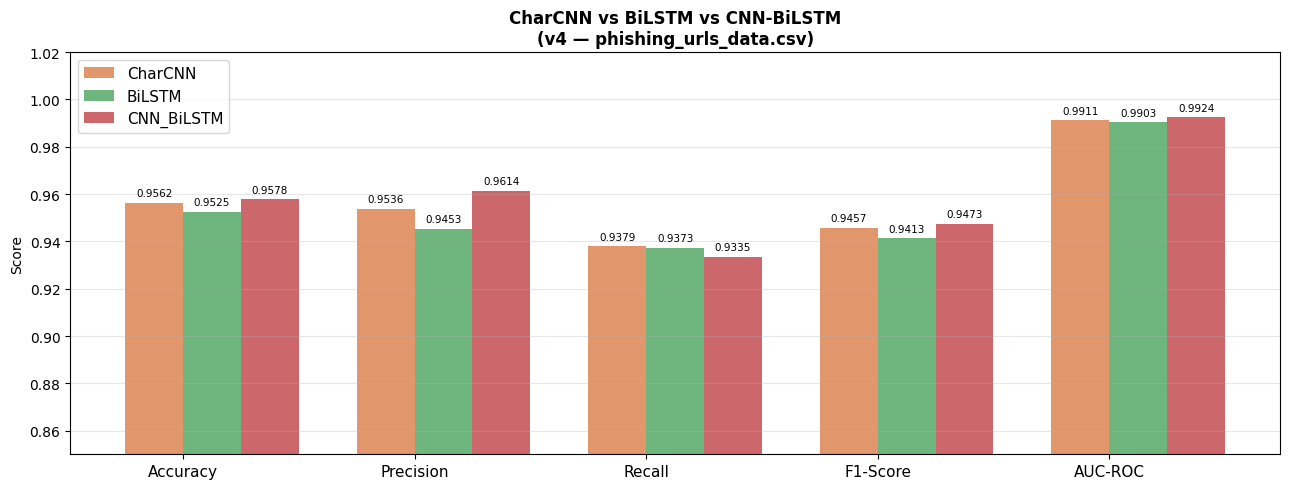

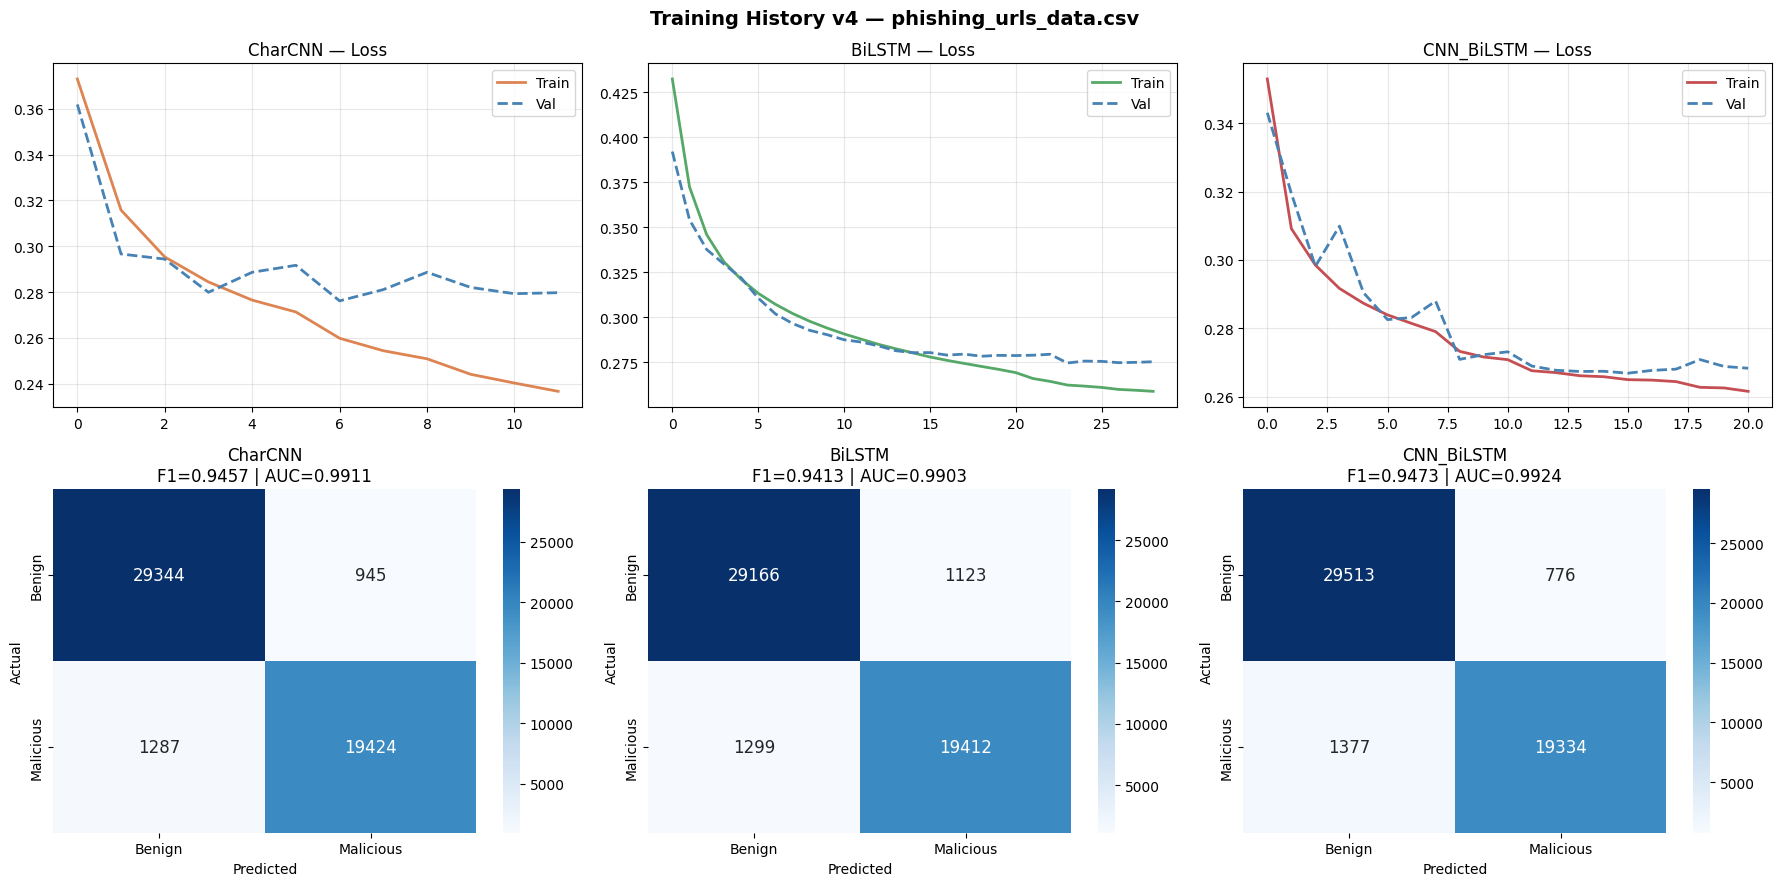

In [ ]:
# ── 9. Bảng so sánh & Biểu đồ ──────────────────────────────────────
cols = ['Model','Accuracy','Precision','Recall','F1-Score','AUC-ROC']
df_cmp = pd.DataFrame([
    {'Model':'XGBoost (baseline)','Accuracy':0.9121,'Precision':0.8869,
     'Recall':0.8988,'F1-Score':0.8928,'AUC-ROC':'-'},
    *[{k:v for k,v in r.items() if k in cols} for r in results]
])
print('\n' + '='*65)
print(f'   📊 KẾT QUẢ — {CSV_FILE}')
print('='*65)
print(df_cmp.to_string(index=False))
best = max(results, key=lambda r: r['F1-Score'])
print(f'\n🏆 Best: {best["Model"]} — F1={best["F1-Score"]} | AUC={best["AUC-ROC"]}')

# Bar chart
metrics = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
colors  = ['#DD8452','#55A868','#C44E52']
fig, ax = plt.subplots(figsize=(13,5))
x = np.arange(len(metrics)); w = 0.25
for i,(res,col) in enumerate(zip(results,colors)):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x+i*w-w, vals, w, label=res['Model'], color=col, alpha=0.85)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+0.002, f'{h:.4f}',
                ha='center', va='bottom', fontsize=7.5)
ax.set_ylim(0.85,1.02)
ax.set_xticks(x-w/2); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score'); ax.legend(fontsize=11)
ax.set_title(f'CharCNN vs BiLSTM vs CNN-BiLSTM\n(v4 — {CSV_FILE})',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves + Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18,9))
fig.suptitle(f'Training History v4 — {CSV_FILE}', fontsize=14, fontweight='bold')
for i,(res,col) in enumerate(zip(results,colors)):
    hist = res['_hist'].history; name = res['Model']
    ax = axes[0,i]
    ax.plot(hist['loss'], label='Train', color=col, linewidth=2)
    ax.plot(hist['val_loss'], label='Val', color='steelblue', linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Loss'); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1,i]
    cm = confusion_matrix(y_test, res['_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign','Malicious'],
                yticklabels=['Benign','Malicious'], annot_kws={'size':12})
    ax.set_title(f'{name}\nF1={res["F1-Score"]} | AUC={res["AUC-ROC"]}')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('training_curves_v4.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 10. Lưu Tokenizer & Download ───────────────────────────────────
tok = {'chars': CHARS, 'vocab_size': VOCAB_SIZE, 'max_len': MAX_LEN}
with open('tokenizer.json', 'w') as f:
    json.dump(tok, f, indent=2)
print('💾 Saved tokenizer.json')

from google.colab import files
for fname in ['CharCNN_phishing.keras','BiLSTM_phishing.keras',
              'CNN_BiLSTM_phishing.keras','tokenizer.json',
              'comparison_v4.png','training_curves_v4.png']:
    try:
        files.download(fname)
        print(f'  ✅ {fname}')
    except Exception as e:
        print(f'  ⚠️  {fname}: {e}')

print('\n' + '='*55)
print('📌 BƯỚC TIẾP THEO:')
print('  1. XÓA file .keras cũ trong phishing_detector\\')
print('  2. Copy 3 file .keras + tokenizer.json mới vào')
print('  3. Khởi động lại API: uvicorn api:app --port 8000')
print('='*55)

💾 Saved tokenizer.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ CharCNN_phishing.keras


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ comparison_v4.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ training_curves_v4.png

📌 BƯỚC TIẾP THEO:
  1. XÓA file .keras cũ trong phishing_detector\
  2. Copy 3 file .keras + tokenizer.json mới vào
  3. Khởi động lại API: uvicorn api:app --port 8000
